You are given a rectangular island heights where heights[r][c] represents the height above sea level of the cell at coordinate (r, c).

The islands borders the Pacific Ocean from the top and left sides, and borders the Atlantic Ocean from the bottom and right sides.

Water can flow in four directions (up, down, left, or right) from a cell to a neighboring cell with height equal or lower. Water can also flow into the ocean from cells adjacent to the ocean.

Find all cells where water can flow from that cell to both the Pacific and Atlantic oceans. Return it as a 2D list where each element is a list [r, c] representing the row and column of the cell. You may return the answer in any order.

Example 1:

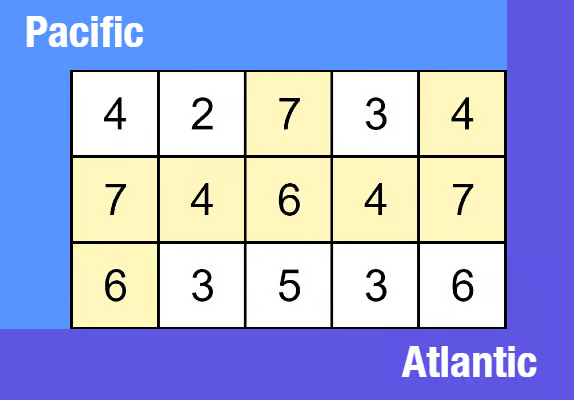

Input: heights = [
  [4,2,7,3,4],
  [7,4,6,4,7],
  [6,3,5,3,6]
]

Output: [[0,2],[0,4],[1,0],[1,1],[1,2],[1,3],[1,4],[2,0]]

Example 2:

Input: heights = [[1],[1]]

Output: [[0,0],[1,0]]

Explanation: The graph has one node with no neighbors.

Example 3:

Input: adjList = []

Output: []

Explanation: The graph is empty.

In [ ]:
from typing import List
from collections import deque

# DFS

Intuition

Instead of starting DFS from every cell (slow), we reverse the thinking:

A cell can reach an ocean if water can flow from that cell to the ocean (downhill/flat).

Reverse it: start from the ocean borders and move uphill/flat (to neighbors with height >= current).

If you can climb from the ocean to a cell, then that cell can flow down to that ocean.

So we do 2 DFS runs:

From all Pacific border cells (top row + left column) → mark all reachable cells in pac

From all Atlantic border cells (bottom row + right column) → mark all reachable cells in atl

Answer = cells that are in both sets.

Algorithm

Create two visited sets: pac, atl.

DFS rule (reverse flow):

From cell (r, c), you may go to a neighbor (nr, nc) only if

heights[nr][nc] >= heights[r][c] (uphill or same).

Run DFS from every Pacific border cell, fill pac.

Run DFS from every Atlantic border cell, fill atl.

For every cell in the grid, if it's in both pac and atl, add it to result.

Return result.

In [ ]:
# Time Complexity: O(m × n)
# Space Complexity: O(m × n)
class Solution:
    def pacificAtlantic(self, heights: List[List[int]]) -> List[List[int]]:
        ROWS, COLS = len(heights), len(heights[0])
        pac, atl = set(), set()

        def dfs(r, c, visit, prevHeight):
            if ((r, c) in visit or
                r < 0 or c < 0 or
                r == ROWS or c == COLS or
                heights[r][c] < prevHeight
            ):
                return
            visit.add((r, c))
            dfs(r + 1, c, visit, heights[r][c])
            dfs(r - 1, c, visit, heights[r][c])
            dfs(r, c + 1, visit, heights[r][c])
            dfs(r, c - 1, visit, heights[r][c])

        for c in range(COLS):
            dfs(0, c, pac, heights[0][c])
            dfs(ROWS - 1, c, atl, heights[ROWS - 1][c])

        for r in range(ROWS):
            dfs(r, 0, pac, heights[r][0])
            dfs(r, COLS - 1, atl, heights[r][COLS - 1])

        res = []
        for r in range(ROWS):
            for c in range(COLS):
                if (r, c) in pac and (r, c) in atl:
                    res.append([r, c])
        return res

# BFS

Intuition

Do the same “reverse flow” idea, but with BFS.

A cell can flow to an ocean if you can start from the ocean border and move backwards into the grid using the rule:

from (r, c) you can go to neighbor (nr, nc) if heights[nr][nc] >= heights[r][c]
(because in the real direction water would flow from higher/equal down to (r, c)).

So:

Multi-source BFS from all Pacific border cells marks pac[r][c] = True

Multi-source BFS from all Atlantic border cells marks atl[r][c] = True

Cells that are True in both are the answer.

Algorithm

Create two boolean grids pac and atl (same size as heights), all false.

Build two source lists:

pacificSources: all cells on top row + left column

atlanticSources: all cells on bottom row + right column

Run BFS(sources, oceanGrid):

Initialize queue with all sources.

While queue not empty:

pop (r, c), mark oceanGrid[r][c] = true

for each neighbor (nr, nc) in 4 directions:

if inside grid AND not visited in oceanGrid AND heights[nr][nc] >= heights[r][c],

push (nr, nc) into queue.

Run BFS for Pacific → fill pac.

Run BFS for Atlantic → fill atl.

Iterate all cells; if pac[r][c] and atl[r][c] are both true, add [r, c] to result.

Return result.

In [ ]:
# Time Complexity: O(m × n)
# Space Complexity: O(m × n)
class Solution:
    def pacificAtlantic(self, heights: List[List[int]]) -> List[List[int]]:
        ROWS, COLS = len(heights), len(heights[0])
        directions = [(1, 0), (-1, 0), (0, 1), (0, -1)]
        pac = [[False] * COLS for _ in range(ROWS)]
        atl = [[False] * COLS for _ in range(ROWS)]

        def bfs(source, ocean):
            q = deque(source)
            while q:
                r, c = q.popleft()
                ocean[r][c] = True
                for dr, dc in directions:
                    nr, nc = r + dr, c + dc
                    if (0 <= nr < ROWS and 0 <= nc < COLS and
                        not ocean[nr][nc] and
                        heights[nr][nc] >= heights[r][c]
                    ):
                        q.append((nr, nc))

        pacific = []
        atlantic = []
        for c in range(COLS):
            pacific.append((0, c))
            atlantic.append((ROWS - 1, c))

        for r in range(ROWS):
            pacific.append((r, 0))
            atlantic.append((r, COLS - 1))

        bfs(pacific, pac)
        bfs(atlantic, atl)

        res = []
        for r in range(ROWS):
            for c in range(COLS):
                if pac[r][c] and atl[r][c]:
                    res.append([r, c])
        return res